# 03 — Module 1: anomaly detection (all five methods)

Five detectors: Isolation Forest, LOF, Z-score, IQR, and an **autoencoder** (PyTorch). Fit on the clean reference, score the incoming batch with injected anomalies, evaluate with ROC-AUC and PR-AUC.

**Requires PyTorch** for the autoencoder: `pip install torch`.

### Calibration note
Anomalies are injected rare + extreme (rate 0.5%, multiplier 1000): the default 2% / x50 is too weak for this dataset's heavy tail (natural 99.9th pct ~592M). Reported with ROC-AUC and PR-AUC.

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from preprocessing import temporal_split, build_module1_features
from injection import inject_anomalies
import module1_anomaly as m1
import module1_autoencoder as ae
DATA_PATH = '../data/HI-Small_Trans.csv'

In [2]:
df = pd.read_csv(DATA_PATH, usecols=['Timestamp','Amount Paid','Is Laundering'])
ref, inc = temporal_split(df, reference_days=3, max_days=10)
ref_fit = ref.sample(100_000, random_state=42).reset_index(drop=True)
inc = inc.sample(100_000, random_state=42).reset_index(drop=True)
print('reference fit:', ref_fit.shape[0], '| incoming test:', inc.shape[0])

reference fit: 100000 | incoming test: 100000


## Fit detectors on the clean reference (incl. the autoencoder)

In [3]:
Xref, scaler, names = build_module1_features(ref_fit, fit=True)
iso = m1.fit_isolation_forest(Xref)
lof = m1.fit_lof(Xref)
autoenc = ae.train_autoencoder(Xref, epochs=20)   # PyTorch
ref_log = Xref[:,0]
print('all five detectors fitted. features:', names)

all five detectors fitted. features: ['log_amount', 'hour', 'dayofweek', 'day']


## Inject anomalies and score all five detectors

In [4]:
RATE, MULT = 0.005, 1000
inc_c, gt = inject_anomalies(inc, 'Amount Paid', rate=RATE, multiplier=MULT, seed=42)
gt = gt.values
Xinc, _, _ = build_module1_features(inc_c, scaler=scaler, fit=False)
scores = {
    'Isolation Forest': m1.score_isolation_forest(iso, Xinc),
    'LOF':              m1.score_lof(lof, Xinc),
    'Z-score':          m1.zscore_scores(Xinc[:,0], ref_values=ref_log)[0],
    'IQR':              m1.iqr_scores(Xinc[:,0], ref_values=ref_log)[0],
    'Autoencoder':      ae.score_autoencoder(autoenc, Xinc),
}
rows = []
for name, s in scores.items():
    e = m1.evaluate(s, gt); tk = m1.evaluate_topk(s, gt, k=RATE)
    rows.append([name, round(e['roc_auc'],3), round(e['pr_auc'],3), round(tk['precision'],3), round(tk['recall'],3)])
pd.DataFrame(rows, columns=['detector','ROC-AUC','PR-AUC','P@topk','R@topk'])

,detector,ROC-AUC,PR-AUC,P@topk,R@topk
0,Isolation Forest,0.807,0.025,0.072,0.072
1,LOF,0.179,0.003,0.008,0.008
2,Z-score,0.883,0.067,0.124,0.124
3,IQR,0.587,0.040,0.124,0.124
4,Autoencoder,0.468,0.007,0.006,0.006


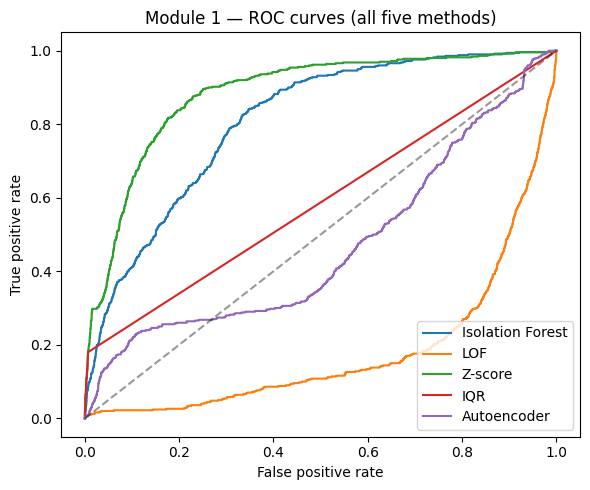

In [5]:
plt.figure(figsize=(6,5))
for name, s in scores.items():
    fpr, tpr, _ = roc_curve(gt, s); plt.plot(fpr, tpr, label=name)
plt.plot([0,1],[0,1],'k--',alpha=0.4)
plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.title('Module 1 — ROC curves (all five methods)'); plt.legend()
plt.tight_layout(); plt.savefig('../results/module1_roc_all.png', dpi=120); plt.show()

## Reading the results
- **Z-score and Isolation Forest are strongest** on this dataset; **LOF fails** (global amount-extremes are its weak point — see the secondary dataset, where LOF succeeds on multi-dimensional fraud).
- **The autoencoder is modest here** because Module 1's features are only 4-dimensional and the anomaly is amount-only, giving a reconstruction method little to exploit. Autoencoders are strongest on high-dimensional data. This is an honest limitation of applying it to this feature set.
- **No single detector dominates**, which is the empirical case for the multi-detector design (Xu et al., 2023; Han et al., 2022).